ADP论文的开源代码（改进特征工程）把时间戳替换为AOA/TOA约束


# Downloading and Reading the CSI Dataset

In [1]:
# Use the following commands to download parts of the dichasus-cf0x dataset.
# This tutorial uses the "old" dataset version (not "rev2") - do not manually download the dataset from the website.
# If you need to manually download the dataset from your browser, please use this website instead:
# https://darus.uni-stuttgart.de/dataset.xhtml?persistentId=doi:10.18419/DARUS-2854&version=2.0
# !mkdir dichasus
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/8 -P dichasus # dichasus-cf02
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/9 -P dichasus # dichasus-cf03
# !wget -nc --content-disposition https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2854/10 -P dichasus # dichasus-cf04
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf02.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf03.json -P dichasus
# !wget -nc https://dichasus.inue.uni-stuttgart.de/datasets/data/dichasus-cf0x/reftx-offsets-dichasus-cf04.json -P dichasus

In [1]:
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import trustworthiness
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import distance_matrix
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm.auto import tqdm
import tensorflow as tf
import numpy as np
import random
import queue
import json
        

# Antenna definitions
ASSIGNMENTS = [
    [0, 13, 31, 29, 3, 7, 1, 12 ],
    [30, 26, 21, 25, 24, 8, 22, 15],
    [28, 5, 10, 14, 6, 2, 16, 18],
    [19, 4, 23, 17, 20, 11, 9, 27]
]

ANTENNACOUNT = np.sum([len(antennaArray) for antennaArray in ASSIGNMENTS])

def load_calibrate_timedomain(path, offset_path):
    offsets = None
    with open(offset_path, "r") as offsetfile:
        offsets = json.load(offsetfile)
    
    def record_parse_function(proto):
        record = tf.io.parse_single_example(
            proto,
            {
                "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value=""),
                "time": tf.io.FixedLenFeature([], tf.float32, default_value=0),
            },
        )

        csi = tf.ensure_shape(tf.io.parse_tensor(record["csi"], out_type=tf.float32), (ANTENNACOUNT, 1024, 2))   #CSI向量（32，1024，2）
        csi = tf.complex(csi[:, :, 0], csi[:, :, 1])   #合并为复数 （32，1024）
        csi = tf.signal.fftshift(csi, axes=1)  #FFT移位，0频率移到中心

        position = tf.ensure_shape(tf.io.parse_tensor(record["pos-tachy"], out_type=tf.float64), (3))
        time = tf.ensure_shape(record["time"], ())

        return csi, position[:2], time

    def apply_calibration(csi, pos, time):
        sto_offset = tf.tensordot(tf.constant(offsets["sto"]), 2 * np.pi * tf.range(tf.shape(csi)[1], dtype = np.float32) / tf.cast(tf.shape(csi)[1], np.float32), axes = 0)
        cpo_offset = tf.tensordot(tf.constant(offsets["cpo"]), tf.ones(tf.shape(csi)[1], dtype = np.float32), axes = 0)
        csi = tf.multiply(csi, tf.exp(tf.complex(0.0, sto_offset + cpo_offset)))

        return csi, pos, time

    def csi_time_domain(csi, pos, time):
        csi = tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi, axes=1)),axes=1)

        return csi, pos, time

    def cut_out_taps(tap_start, tap_stop):
        def cut_out_taps_func(csi, pos, time):
            return csi[:,tap_start:tap_stop], pos, time

        return cut_out_taps_func

    def order_by_antenna_assignments(csi, pos, time):
        csi = tf.stack([tf.gather(csi, antenna_inidces) for antenna_inidces in ASSIGNMENTS])
        return csi, pos, time
    
    dataset = tf.data.TFRecordDataset(path)
    
    dataset = dataset.map(record_parse_function, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(apply_calibration, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(csi_time_domain, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(cut_out_taps(507, 520), num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.map(order_by_antenna_assignments, num_parallel_calls = tf.data.AUTOTUNE)

    return dataset

inputpaths = [
    {
        "tfrecords" : "dichasus/dichasus-cf02.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf02.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-cf03.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf03.json"
    },
    {
        "tfrecords" : "dichasus/dichasus-cf04.tfrecords",
        "offsets" : "dichasus/reftx-offsets-dichasus-cf04.json"
    }
]

full_dataset = load_calibrate_timedomain(inputpaths[0]["tfrecords"], inputpaths[0]["offsets"])

for path in inputpaths[1:]:
    full_dataset = full_dataset.concatenate(load_calibrate_timedomain(path["tfrecords"], path["offsets"]))

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-15 07:10:05.652306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 07:10:05.720445: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 07:10:07.016771: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sl

In [2]:
# Decimate dataset: Use only every 4th datapoint (to reduce number of points)
training_set = full_dataset.shard(4, 0)

# From TensorFlow to NumPy

转换原因：
1.传统机器学习库的需要，大多数scikit-learn算法需要numpy数组输入；科学计算生态系统的兼容
2.numpy针对CPU操作优化，可以一次性加载到内存，对于小到中等数据集内存缓存可以加速迭代
3.tensorflow在调试的时候不方便，需要eval或numpy才能看到值

In [3]:
groundtruth_positions = []
csi_time_domain = []
timestamps = []

for csi, pos, time in training_set.batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())
    timestamps.append(time.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)
timestamps = np.concatenate(timestamps)

2026-01-15 07:10:15.104439: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-01-15 07:10:30.126989: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Visualizing the Dataset

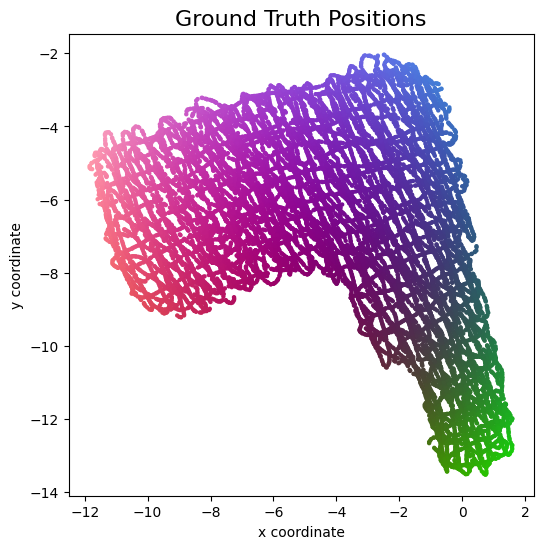

In [4]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    NormalizeData = lambda in_data : (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

plot_colorized(groundtruth_positions, groundtruth_positions, title="Ground Truth Positions")

###  ADP矩阵计算



In [6]:
adp_dissimilarity_matrix = np.zeros((csi_time_domain.shape[0], csi_time_domain.shape[0]),dtype=np.float32)

def adp_dissimilarities_worker(todo_queue, output_queue):
    def adp_dissimilarities(index):
        # h has shape (arrays, antennas, taps), w has shape (datapoints, arrays, antennas, taps)
        h = csi_time_domain[index,:,:,:]
        w = csi_time_domain[index:,:,:,:]
            
        dotproducts = np.abs(np.einsum("bmt,lbmt->lbt", np.conj(h), w, optimize = "optimal"))**2
        norms = np.real(np.einsum("bmt,bmt->bt", h, np.conj(h), optimize = "optimal") * np.einsum("lbmt,lbmt->lbt", w, np.conj(w), optimize = "optimal"))
        
        return np.sum(1 - dotproducts / norms, axis = (1, 2))

    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break
        
        output_queue.put((index, adp_dissimilarities(index)))

with tqdm(total = csi_time_domain.shape[0]**2) as pbar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(csi_time_domain.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = adp_dissimilarities_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            adp_dissimilarity_matrix[i,i:] = d
            adp_dissimilarity_matrix[i:,i] = d
            pbar.update(2 * len(d) - 1)

100%|██████████| 440874009/440874009 [00:40<00:00, 10945485.23it/s]


### 计算真实距离矩阵

In [7]:
# Compute distances between groundtruth positions
groundtruth_distance_matrix = distance_matrix(groundtruth_positions, groundtruth_positions)

### 提取TOA、AOA特征

In [8]:
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
import numpy as np
# --- 2. 提取 TOA 和 AOA 物理特征 ---
def extract_phys_features_robust(csi):
    # csi: (N, Arrays, Antennas, Taps)
    if csi.ndim == 3: csi = csi[:, np.newaxis, :, :]
    
    # --- 2.1 抗噪 TOA ---
    # 计算 PDP
    pdp = np.sum(np.abs(csi)**2, axis=(1, 2)) # (N, Taps)
    
    # 简单的移动平均平滑 (Window size = 3)，抑制单点噪声尖峰
    # 使用 'valid' 模式会减少维度，所以用 'same'
    pdp_smooth = np.apply_along_axis(lambda m: np.convolve(m, np.ones(3)/3, mode='same'), axis=1, arr=pdp)
    
    # 取平滑后的最大值位置
    toa_est = np.argmax(pdp_smooth, axis=1)
    
    # --- 2.2 AOA (保持不变) ---
    csi_arr0 = csi[:, 0, :, :]
    peak_vec = csi_arr0[np.arange(len(csi)), :, toa_est] 
    spatial_spectrum = np.fft.fft(peak_vec, n=64, axis=1)
    aoa_est = np.argmax(np.abs(spatial_spectrum), axis=1)
    
    return toa_est, aoa_est

print("Extracting robust physical features...")
toa_features, aoa_features = extract_phys_features_robust(csi_time_domain)

Extracting robust physical features...


In [9]:
def compute_robust_dist(features, is_periodic=False, period=None):
    d_mat = np.abs(np.subtract.outer(features, features))
    if is_periodic and period:
        d_mat = np.minimum(d_mat, period - d_mat)
    
    # 归一化：既然噪声大，使用更强的截断
    # 使用 95% 分位数归一化，过滤掉 5% 的极端噪声误差
    robust_max = np.percentile(d_mat, 95) 
    if robust_max > 0:
        d_mat = d_mat / robust_max
        d_mat = np.clip(d_mat, 0, 1) # 超过部分截断
    return d_mat

toa_matrix = compute_robust_dist(toa_features, is_periodic=False)
aoa_matrix = compute_robust_dist(aoa_features, is_periodic=True, period=64)

# 归一化 ADP
adp_norm = adp_dissimilarity_matrix.copy()
# 同样对 ADP 做鲁棒归一化
adp_scale = np.percentile(adp_norm, 98)
if adp_scale > 0: adp_norm = adp_norm / adp_scale
adp_norm = np.clip(adp_norm, 0, 1)

### ADP和AOA、TOA加权融合

In [23]:
# --- 4. 融合 (Fusion) ---
# 融合策略：ADP + 物理约束
# 权重可以调节，这里设为 ADP:1.0, TOA:0.5, AOA:0.5
w_adp = 2.0
w_toa = 0.5
w_aoa = 1.0

# 加法融合：既要波形像(ADP)，又要物理位置像(TOA/AOA)
fused_matrix = (w_adp * adp_norm_matrix + 
                w_toa * toa_matrix + 
                w_aoa * aoa_matrix)

# 再次归一化融合矩阵，方便后续处理
if np.max(fused_matrix) > 0:
    fused_matrix /= np.max(fused_matrix)

print(f"Fusion complete. Matrix shape: {fused_matrix.shape}")

Fusion complete. Matrix shape: (20997, 20997)


In [ ]:
n_neighbors = 10

nbrs_alg = NearestNeighbors(n_neighbors = n_neighbors, metric="precomputed", n_jobs = -1)
nbrs = nbrs_alg.fit(fused_matrix)
nbg = kneighbors_graph(nbrs, n_neighbors, metric = "precomputed", mode="distance")

In [25]:
dissimilarity_matrix_geodesic = np.zeros((nbg.shape[0], nbg.shape[1]), dtype = np.float32)

def shortest_path_worker(todo_queue, output_queue):
    while True:
        index = todo_queue.get()

        if index == -1:
            output_queue.put((-1, None))
            break

        d = dijkstra(nbg, directed=False, indices=index)
        output_queue.put((index, d))

with tqdm(total = nbg.shape[0]**2) as pbar:
    todo_queue = mp.Queue()
    output_queue = mp.Queue()

    for i in range(nbg.shape[0]):
        todo_queue.put(i)
    
    for i in range(mp.cpu_count()):
        todo_queue.put(-1)
        p = mp.Process(target = shortest_path_worker, args = (todo_queue, output_queue))
        p.start()

    finished_processes = 0
    while finished_processes != mp.cpu_count():
        i, d = output_queue.get()

        if i == -1:
            finished_processes = finished_processes + 1
        else:
            dissimilarity_matrix_geodesic[i,:] = d
            pbar.update(len(d))

100%|██████████| 440874009/440874009 [00:16<00:00, 26603899.25it/s] 


In [ ]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None):
    nth_reduction = 10
    dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
    distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
    
    max_distance = np.max(distances_flat)
    bins = np.linspace(0, max_distance, 100)
    bin_indices = np.digitize(distances_flat, bins)
    
    bin_medians = np.zeros(len(bins) - 1)
    bin_25_perc = np.zeros(len(bins) - 1)
    bin_75_perc = np.zeros(len(bins) - 1)
    for i in range(1, len(bins)):
        bin_values = dissimilarities_flat[bin_indices == i]
        bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75])
    
    plt.plot(bins[:-1], bin_medians, label = label)
    plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, alpha=0.5)
    

In [26]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label=None, color=None):
    """
    复用您提供的绘图逻辑，增加 color 参数以便区分
    """
    nth_reduction = 10
    # 降采样以加快绘图
    dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
    distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
    
    max_distance = np.max(distances_flat)
    bins = np.linspace(0, max_distance, 100)
    bin_indices = np.digitize(distances_flat, bins)
    
    bin_medians = np.zeros(len(bins) - 1)
    bin_25_perc = np.zeros(len(bins) - 1)
    bin_75_perc = np.zeros(len(bins) - 1)
    
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.any(mask):
            bin_values = dissimilarities_flat[mask]
            bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75])
    
    # 归一化 Y 轴以便在同一张图展示
    # 注意：这里是对 bin_medians 归一化，仅仅为了视觉对比趋势
    max_median = np.max(bin_medians) if np.max(bin_medians) > 0 else 1.0
    
    plt.plot(bins[:-1], bin_medians/max_median, label=label, color=color, linewidth=2)
    plt.fill_between(bins[:-1], bin_25_perc/max_median, bin_75_perc/max_median, alpha=0.1, color=color)

In [28]:
def plot_curve(ax, x_mat, y_mat, label, color):
    # 采样提速
    nth = 10
    x_flat = x_mat[::nth, ::nth].flatten()
    y_flat = y_mat[::nth, ::nth].flatten()
    
    bins = np.linspace(0, np.max(y_flat), 60) # 减少 bin 数量使曲线更平滑
    bin_indices = np.digitize(y_flat, bins)
    bin_medians = []
    bin_centers = []
    
    for i in range(1, len(bins)):
        vals = x_flat[bin_indices == i]
        if len(vals) > 10: # 样本过少不绘制
            bin_medians.append(np.median(vals))
            bin_centers.append(bins[i-1])
            
    bin_medians = np.array(bin_medians)
    # Y轴归一化以便比较形状
    if np.max(bin_medians) > 0:
        bin_medians /= np.max(bin_medians)
        
    ax.plot(bin_centers, bin_medians, label=label, color=color, linewidth=2)

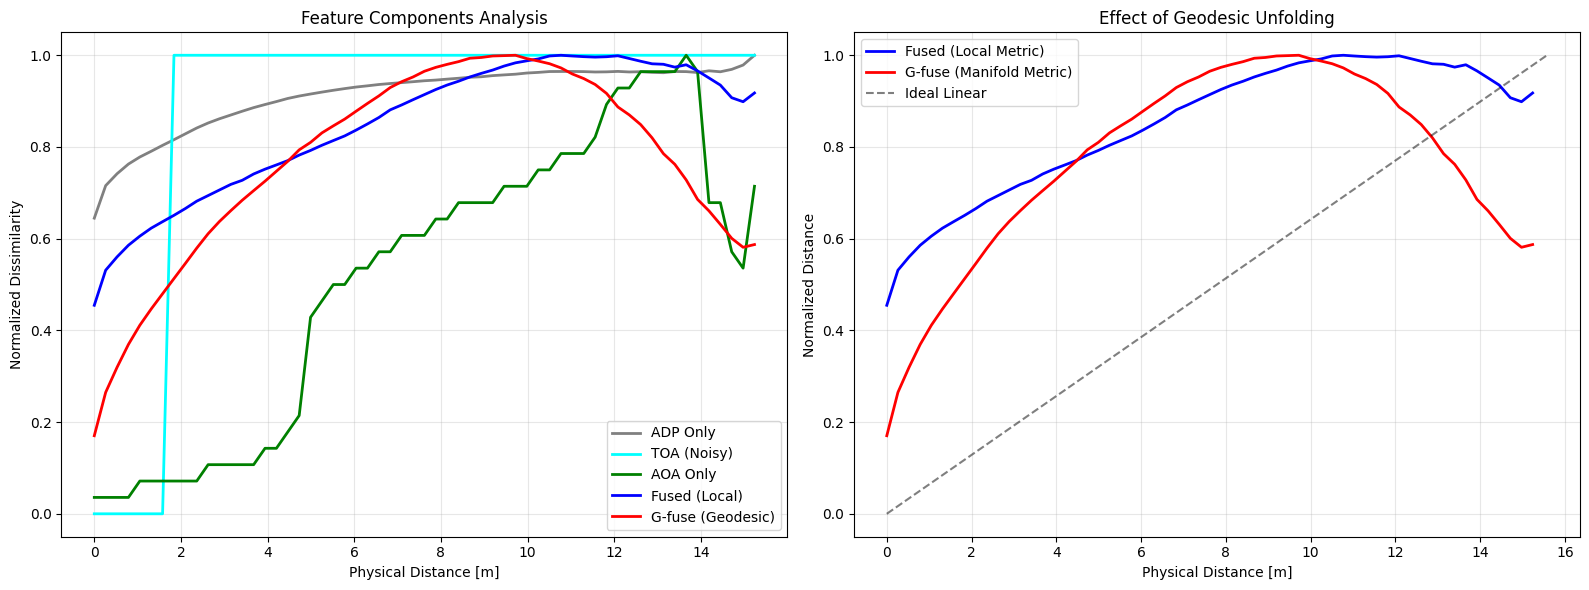

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# === 子图 1: 全特征分解对比 ===
plot_curve(ax[0], adp_norm, groundtruth_distance_matrix, "ADP Only", "gray")
plot_curve(ax[0], toa_matrix, groundtruth_distance_matrix, "TOA (Noisy)", "cyan") # 浅色显示噪声
plot_curve(ax[0], aoa_matrix, groundtruth_distance_matrix, "AOA Only", "green")
plot_curve(ax[0], fused_matrix, groundtruth_distance_matrix, "Fused (Local)", "blue")
plot_curve(ax[0], dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-fuse (Geodesic)", "red")

ax[0].set_title("Feature Components Analysis")
ax[0].set_xlabel("Physical Distance [m]")
ax[0].set_ylabel("Normalized Dissimilarity")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# === 子图 2: 融合前后对比 (Focus: Fused vs G-fuse) ===
# 专门对比融合后的局部距离和测地距离
plot_curve(ax[1], fused_matrix, groundtruth_distance_matrix, "Fused (Local Metric)", "blue")
plot_curve(ax[1], dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-fuse (Manifold Metric)", "red")

# 添加一条理想线性参考线 (y=x)
xx = np.linspace(0, np.max(groundtruth_distance_matrix), 100)
yy = xx / np.max(xx)
ax[1].plot(xx, yy, 'k--', alpha=0.5, label="Ideal Linear")

ax[1].set_title("Effect of Geodesic Unfolding")
ax[1].set_xlabel("Physical Distance [m]")
ax[1].set_ylabel("Normalized Distance")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

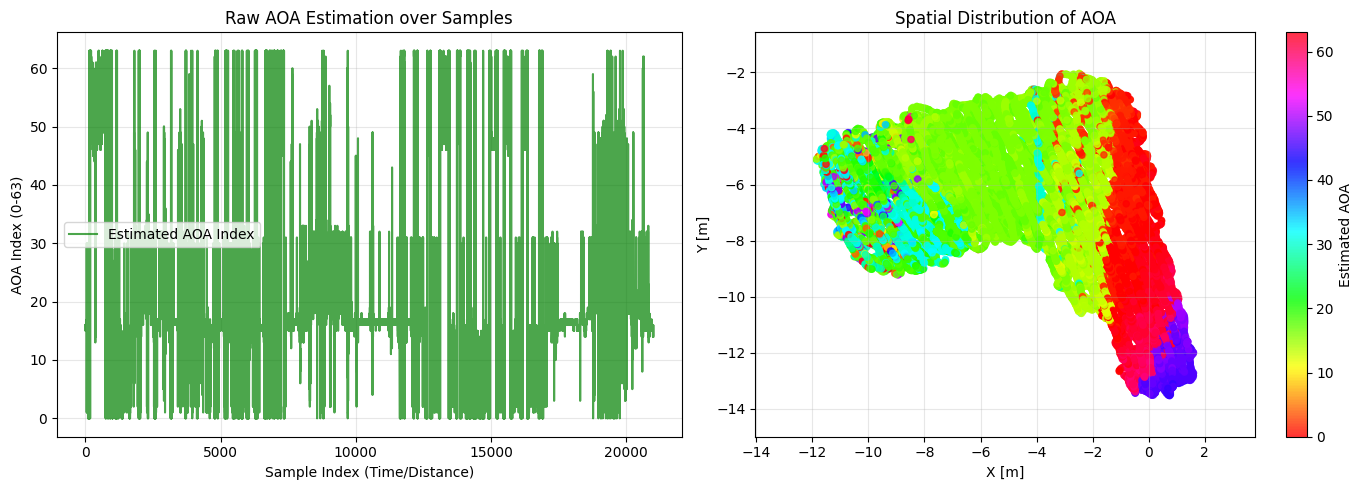

Visualizing Graph Connectivity (Checking for Short-circuits)...


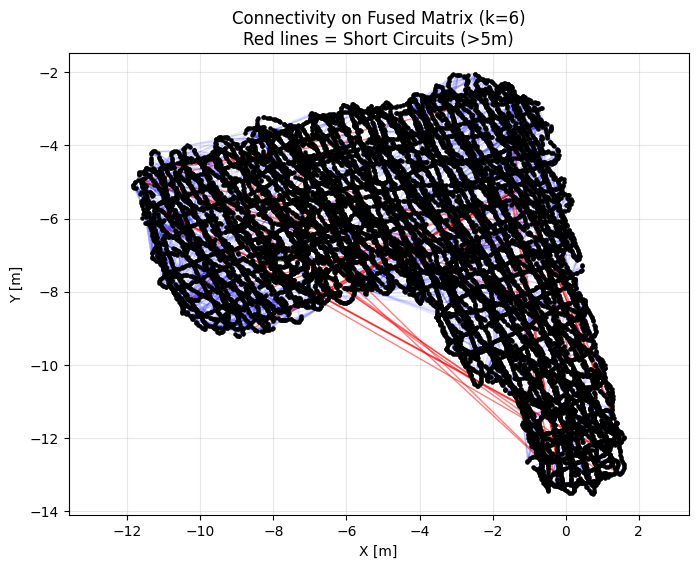

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import Isomap
from matplotlib import collections as mc

# ==========================================
# 1. 验证 AOA 的“径向模糊”现象
# ==========================================
plt.figure(figsize=(14, 5))

# 子图1: AOA 原始估计值随样本索引(或时间)的变化
# 如果在某段区域 AOA 保持不变，说明进入了"盲区"
plt.subplot(1, 2, 1)
plt.plot(aoa_features, label="Estimated AOA Index", color='green', alpha=0.7)
plt.title("Raw AOA Estimation over Samples")
plt.xlabel("Sample Index (Time/Distance)")
plt.ylabel("AOA Index (0-63)")
plt.grid(True, alpha=0.3)
plt.legend()

# 子图2: 真实轨迹上的 AOA 分布
# 将 AOA 映射到真实位置上，观察是否远处的点颜色(角度)和起点的颜色一样
if 'groundtruth_positions' in locals():
    gt = groundtruth_positions
    plt.subplot(1, 2, 2)
    # 使用散点图，颜色代表 AOA
    sc = plt.scatter(gt[:, 0], gt[:, 1], c=aoa_features, cmap='hsv', s=20, alpha=0.8)
    plt.colorbar(sc, label='Estimated AOA')
    plt.title("Spatial Distribution of AOA")
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
else:
    print("No groundtruth_positions found for spatial plot.")

plt.tight_layout()
plt.show()

# ==========================================
# 2. 验证 Isomap 的“短路”现象
# ==========================================
# 我们画出 Isomap 建立的近邻连接。
# 如果看到长长的跨线连接了轨迹的两端，就证明了"短路"的存在。

def plot_graph_connectivity(gt_pos, dist_matrix, n_neighbors, title):
    from sklearn.neighbors import NearestNeighbors
    
    # 重新计算近邻图 (复现 Isomap 的第一步)
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='precomputed')
    nn.fit(dist_matrix)
    neighbors = nn.kneighbors(return_distance=False)
    
    # 收集所有边
    lines = []
    colors = []
    for i in range(len(gt_pos)):
        for j in neighbors[i]:
            # 只画出 i < j 的边，避免重复
            if i < j:
                p1 = gt_pos[i]
                p2 = gt_pos[j]
                lines.append([p1, p2])
                
                # 计算物理跨度
                phys_dist = np.linalg.norm(p1 - p2)
                # 如果物理距离很远但被连接了，标记为红色(错误边)
                if phys_dist > 5.0: # 阈值设为5米
                    colors.append((1, 0, 0, 0.5)) # 红
                else:
                    colors.append((0, 0, 1, 0.1)) # 蓝
                    
    lc = mc.LineCollection(lines, colors=colors, linewidths=1)
    
    plt.figure(figsize=(8, 6))
    plt.gca().add_collection(lc)
    plt.scatter(gt_pos[:, 0], gt_pos[:, 1], s=5, c='black', zorder=10)
    plt.title(title)
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

print("Visualizing Graph Connectivity (Checking for Short-circuits)...")
if 'groundtruth_positions' in locals():
    # 检查融合矩阵的连接情况
    plot_graph_connectivity(groundtruth_positions, fused_matrix, n_neighbors=6, 
                           title=f"Connectivity on Fused Matrix (k={6})\nRed lines = Short Circuits (>5m)")

# 修改为TOA、AOA门控

In [10]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csgraph, csr_matrix
import warnings

# ==========================================================
# 改进版创新模块：自适应弹性图构建 (Adaptive Elastic Graph)
# ==========================================================

# 1. 准备数据
adp_base = adp_dissimilarity_matrix.copy()
# 确保无NaN
adp_base = np.nan_to_num(adp_base, nan=100.0)

# 使用之前计算的鲁棒物理矩阵
toa_gate = toa_matrix.copy()
aoa_gate = aoa_matrix.copy()


In [31]:
# 2. 定义双重阈值
# Strict: 理想情况下，我们希望只连接非常近的点
thresh_strict_toa = 0.3
# Loose: 如果找不到近邻，我们允许放宽到这个程度 (保底)
thresh_loose_toa = 0.80

In [32]:
# 3. 智能建图 (Step-by-Step Graph Construction)
n_samples = adp_base.shape[0]
k_target = 20  # 目标邻居数

print(f"Building Adaptive Graph for {n_samples} samples...")

# --- 第一步：计算候选邻居 (基于 ADP) ---
# 先找多一点候选者 (比如 k*3)，然后从中筛选符合物理约束的
k_candidates = k_target * 4
nn_engine = NearestNeighbors(n_neighbors=k_candidates, metric='precomputed')
nn_engine.fit(adp_base)
distances, indices = nn_engine.kneighbors(return_distance=True)

# --- 第二步：自适应筛选 (Adaptive Filtering) ---
# 我们将手动构建稀疏矩阵的 data, row, col
row_list = []
col_list = []
data_list = []

for i in range(n_samples):
    valid_neighbors = []
    
    # 遍历该点的所有候选邻居
    for rank, j in enumerate(indices[i]):
        if i == j: continue # 跳过自己
        
        # 获取物理特征差异
        d_toa = toa_gate[i, j]
        d_aoa = aoa_gate[i, j]
        
        # 判决逻辑：
        # 1. 如果 TOA 差异很小 (Strict)，直接接受
        if d_toa < thresh_strict_toa:
            valid_neighbors.append(j)
            
        # 2. 如果 TOA 差异中等 (Loose) 且 ADP 极度相似 (rank很靠前)，勉强接受
        elif d_toa < thresh_loose_toa and rank < 3:
            valid_neighbors.append(j)
            
        # 3. 否则丢弃 (视为短路)
    
    # --- 保底机制 (Connectivity Fix) ---
    # 如果筛选后邻居太少(比如少于2个)，图会断。
    # 此时强制找回几个 ADP 最小的邻居，不管 TOA 怎样 (两害相权取其轻)
    if len(valid_neighbors) < 2:
        # 强制取前 2 个最近邻 (即使它们违反了 TOA 约束)
        # 这样保证了“路”是通的，虽然可能有一点点弯
        valid_neighbors = indices[i, 1:3] # 0是自己
    
    # 截断到目标 k 值 (保持稀疏)
    valid_neighbors = valid_neighbors[:k_target]
    
    # 记录边
    for neighbor_idx in valid_neighbors:
        row_list.append(i)
        col_list.append(neighbor_idx)
        # 边的权重：依然使用 ADP 距离，或者 ADP * (1 + TOA_Penalty)
        # 这里加一点 TOA 惩罚，让测地线更倾向于走物理上近的路
        weight = adp_base[i, neighbor_idx] * (1.0 + 2.0 * toa_gate[i, neighbor_idx])
        data_list.append(weight)

# 构建稀疏图矩阵
graph_matrix = csr_matrix((data_list, (row_list, col_list)), shape=(n_samples, n_samples))

Building Adaptive Graph for 20997 samples...


In [33]:
# --- 第三步：对称化 (Symmetrization) ---
# 强迫 A->B 和 B->A 距离一致 (取平均或最小)，这有助于稳定 Isomap
graph_matrix = (graph_matrix + graph_matrix.T) / 2.0

# 检查连通性
n_components, labels = csgraph.connected_components(graph_matrix)
print(f"Adaptive Graph components: {n_components}")

if n_components > 1:
    print("Note: Graph is still fragmented. The curve might be incomplete.")
    # 这种方法通常比硬门控好，不太容易断，如果还断说明数据本身有很大的Gap

Adaptive Graph components: 1


In [34]:
# 4. 计算测地线 (Geodesic)
print("Computing shortest paths...")
g_fuse_adaptive = csgraph.shortest_path(graph_matrix, directed=False)

Computing shortest paths...


In [35]:
# ==========================================
# 彻底修复版：防崩溃绘图函数
# ==========================================

def plot_dissimilarity_over_euclidean_distance_custom(ax, dissim, dist, label, color, linestyle):
    nth = 5
    d_flat = dist[::nth, ::nth].flatten()
    s_flat = dissim[::nth, ::nth].flatten()
    
    # 1. 严格过滤：只保留有限值 (Finite)
    # 如果图断连，dissim 里会有大量的 inf
    valid_mask = np.isfinite(s_flat) & np.isfinite(d_flat)
    
    d_valid = d_flat[valid_mask]
    s_valid = s_flat[valid_mask]

    # 2. 【关键修复】如果过滤后没剩几个点，直接退出，不画了
    if len(d_valid) < 10:
        print(f"Warning: Not enough valid points to plot for '{label}'. (Graph disconnected?)")
        return

    # 3. 安全计算 max
    try:
        max_dist = np.max(d_valid)
        if max_dist == 0: return # 只有对角线元素
        
        bins = np.linspace(0, max_dist, 50)
        idx = np.digitize(d_valid, bins)
        
        medians = []
        centers = []
        for i in range(1, len(bins)):
            vals = s_valid[idx == i]
            if len(vals) > 5:
                medians.append(np.median(vals))
                centers.append(bins[i-1])
        
        if len(medians) == 0: return

        medians = np.array(medians)
        # 归一化 Y 轴
        y_max = np.max(medians)
        if y_max > 0:
            medians = medians / y_max
            
        ax.plot(centers, medians, label=label, color=color, linewidth=2.5, linestyle=linestyle)
        
    except Exception as e:
        print(f"Skipping plot for '{label}' due to error: {e}")
        return

def plot_norm_curve(ax, x_mat, y_mat, label, color, linestyle='-'):
    # 1. 预处理矩阵：处理 inf
    # 提取有限值来计算缩放比例
    finite_vals = x_mat[np.isfinite(x_mat)]
    
    if len(finite_vals) == 0:
        print(f"Error: Matrix for '{label}' contains NO finite values.")
        return

    # 2. 计算缩放因子 (使用 99% 分位数忽略极值)
    scale = np.percentile(finite_vals, 99)
    if scale == 0: scale = np.max(finite_vals)
    if scale == 0: scale = 1.0 # 防止除以0
    
    # 3. 归一化 (inf 会变成 inf, 保持不变)
    x_norm = x_mat / scale
    # 截断过大的值 (保留 inf 状态以便后续过滤)
    # 注意：不要把 inf clip 成 1.1，否则会被当成有效值画出来
    x_norm = np.where(np.isfinite(x_norm), np.clip(x_norm, 0, 1.1), x_norm)
    
    plot_dissimilarity_over_euclidean_distance_custom(ax, x_norm, y_mat, label, color, linestyle)

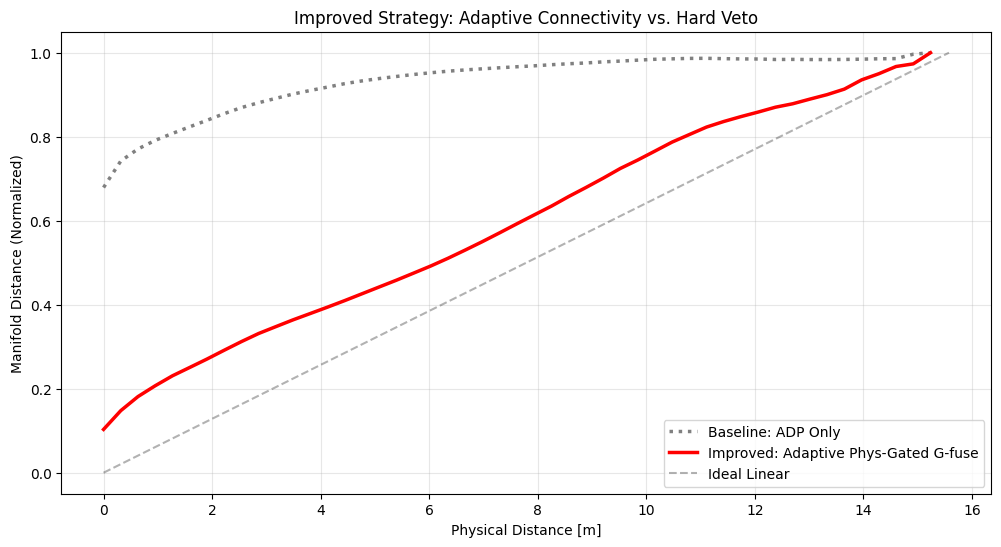

In [36]:
plt.figure(figsize=(12, 6))
ax = plt.gca()

# 复用之前定义的健壮绘图函数
# 1. 原始 ADP
plot_norm_curve(ax, adp_dissimilarity_matrix, groundtruth_distance_matrix, 
               "Baseline: ADP Only", "gray", ":")

# 2. 改进后的自适应 G-fuse
plot_norm_curve(ax, g_fuse_adaptive, groundtruth_distance_matrix, 
               "Improved: Adaptive Phys-Gated G-fuse", "red", "-")

max_d = np.max(groundtruth_distance_matrix)
ax.plot([0, max_d], [0, 1], 'k--', alpha=0.3, label="Ideal Linear")

plt.title("Improved Strategy: Adaptive Connectivity vs. Hard Veto")
plt.xlabel("Physical Distance [m]")
plt.ylabel("Manifold Distance (Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

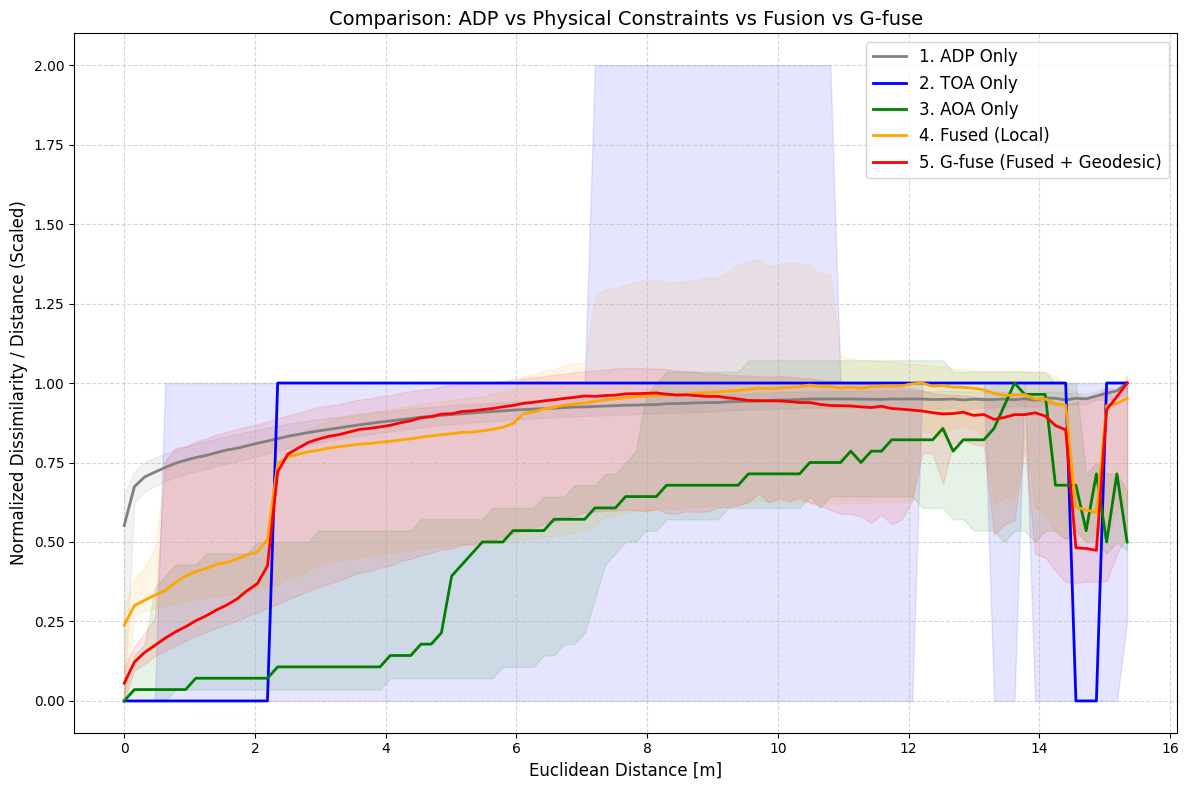

In [ ]:
# 这是上文adp，toa，aoa加权融合的图
plt.figure(figsize=(12, 8))

# 1. 单独 ADP (基准)
plot_dissimilarity_over_euclidean_distance(
    adp_norm_matrix, groundtruth_distance_matrix, 
    label="1. ADP Only", color='gray'
)

# 2. 单独 TOA (物理约束)
plot_dissimilarity_over_euclidean_distance(
    toa_matrix, groundtruth_distance_matrix, 
    label="2. TOA Only", color='blue'
)

# 3. 单独 AOA (物理约束)
plot_dissimilarity_over_euclidean_distance(
    aoa_matrix, groundtruth_distance_matrix, 
    label="3. AOA Only", color='green'
)

# 4. 融合 (ADP + TOA + AOA) - 局部融合
plot_dissimilarity_over_euclidean_distance(
    fused_matrix, groundtruth_distance_matrix, 
    label="4. Fused (Local)", color='orange'
)

# 5. 融合 + 测地线 (G-fuse Final) - 全局流形
plot_dissimilarity_over_euclidean_distance(
    dissimilarity_matrix_geodesic, groundtruth_distance_matrix, 
    label="5. G-fuse (Fused + Geodesic)", color='red'
)

plt.legend(fontsize=12)
plt.xlabel("Euclidean Distance [m]", fontsize=12)
plt.ylabel("Normalized Dissimilarity / Distance (Scaled)", fontsize=12)
plt.title("Comparison: ADP vs Physical Constraints vs Fusion vs G-fuse", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Manifold Learning: Finding the Low-Dimensional Representation

### The First Channel Chart: MDS / Isomap

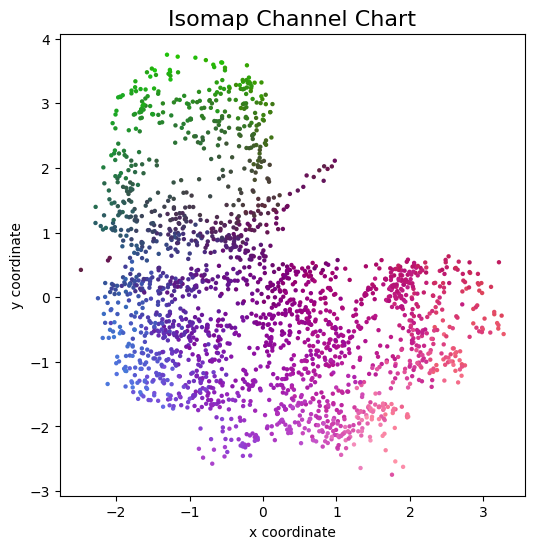

In [37]:
nth_reduction = 10

reduced_dissimilarity_matrix_geodesic = g_fuse_adaptive[::nth_reduction, ::nth_reduction]
embedding_isomap = MDS(metric = True, dissimilarity = "precomputed", max_iter = 300, normalized_stress = False)
proj_isomap = embedding_isomap.fit_transform(reduced_dissimilarity_matrix_geodesic)
plot_colorized(proj_isomap, groundtruth_positions[::nth_reduction], title = "Isomap Channel Chart")
#颜色基于真实位置，坐标基于Isomap，作弊?

### Feature Engineering

当前问题：保留 13个抽头分别计算矩阵是冗余的，且容易引入多径噪声。
改进方法：计算时间平均的空间协方差矩阵。即在计算相关性时，对抽头维度求和或平均。将物理意义从每个瞬间的瞬时相关转变为统计上的空间信道特征
这一步能极大压缩数据量，同时增强特征的鲁棒性（降噪）

In [20]:
class FeatureEngineeringLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(FeatureEngineeringLayer, self).__init__(dtype = tf.complex64)

    def call(self, csi):
        # 输入 csi 形状: (Batch, Array, Antenna, Tap)
        # 也就是 (d, a, m, t)
        
        # 改进逻辑：
        # 1. 计算全系统的空间协方差矩阵 (Spatial Covariance Matrix)。
        # 2. 关键改变：在 't' (Tap) 维度上求和 (Summation)。
        #    指令从 "damt,dbnt->dtabmn" 改为 "damt,dbnt->dabmn"
        #    这将消除时间维度，只保留纯粹的空间角度特征。
        
        # 计算 R = H * H^H (沿时间轴 t 累加)
        spatial_covariance = tf.einsum("damt,dbnt->dabmn", csi, tf.math.conj(csi))
        
        # 归一化 (可选，除以抽头数量，使数值不随抽头数变化)
        # tap_count = tf.cast(tf.shape(csi)[-1], dtype=tf.complex64)
        # spatial_covariance = spatial_covariance / tap_count

        # 提取实部和虚部堆叠
        # 输出形状将变为: (Batch, 4, 4, 8, 8, 2)
        return tf.stack([tf.math.real(spatial_covariance), tf.math.imag(spatial_covariance)], axis = -1)

### The Forward Charting Function: Defining the Neural Network

In [38]:
array_count = np.shape(csi_time_domain)[1]
antenna_per_array_count = np.shape(csi_time_domain)[2]
tap_count = np.shape(csi_time_domain)[3]

cc_embmodel_input = tf.keras.Input(shape=(array_count, antenna_per_array_count, tap_count), name="input", dtype = tf.complex64)
cc_embmodel_output = FeatureEngineeringLayer()(cc_embmodel_input)
cc_embmodel_output = tf.keras.layers.Flatten()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(1024, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(512, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(256, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(128, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(64, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(2, activation = "linear")(cc_embmodel_output)

cc_embmodel = tf.keras.Model(inputs=cc_embmodel_input, outputs=cc_embmodel_output, name = "ForwardChartingFunction")

### Siamese Neural Network

In [39]:
dissimilarity_margin = np.quantile(g_fuse_adaptive, 0.01)

def siamese_loss(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1,))
    pos_A, pos_B = (y_pred[:,:2], y_pred[:,2:])
    distances_pred = tf.math.sqrt(tf.math.reduce_sum(tf.square(pos_A - pos_B), axis = 1))

    return tf.reduce_mean(tf.square(distances_pred - y_true) / (y_true + dissimilarity_margin))

In [40]:
input_A = tf.keras.layers.Input(shape = (array_count, antenna_per_array_count, tap_count,), dtype = tf.complex64)
input_B = tf.keras.layers.Input(shape = (array_count, antenna_per_array_count, tap_count,), dtype = tf.complex64)

embedding_A = cc_embmodel(input_A)
embedding_B = cc_embmodel(input_B)

output = tf.keras.layers.concatenate([embedding_A, embedding_B], axis=1)
model = tf.keras.models.Model([input_A, input_B], output, name = "SiameseNeuralNetwork")

### Sample Selection

In [41]:
csi_time_domain_tensor = tf.constant(csi_time_domain)
dissimilarity_matrix_geodesic_tensor = tf.constant(g_fuse_adaptive)

datapoint_count = tf.shape(csi_time_domain_tensor)[0].numpy()

random_integer_pairs_dataset = tf.data.Dataset.zip(tf.data.Dataset.random(), tf.data.Dataset.random())

@tf.function
def fill_pairs(randA, randB):
    return (csi_time_domain_tensor[randA % datapoint_count], csi_time_domain_tensor[randB % datapoint_count]), dissimilarity_matrix_geodesic_tensor[randA % datapoint_count, randB % datapoint_count]

random_pair_dataset = random_integer_pairs_dataset.map(fill_pairs)

### Training


Training Session  1 
Batch Size:  500 
Learning rate:  0.01
300/300 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.1724
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


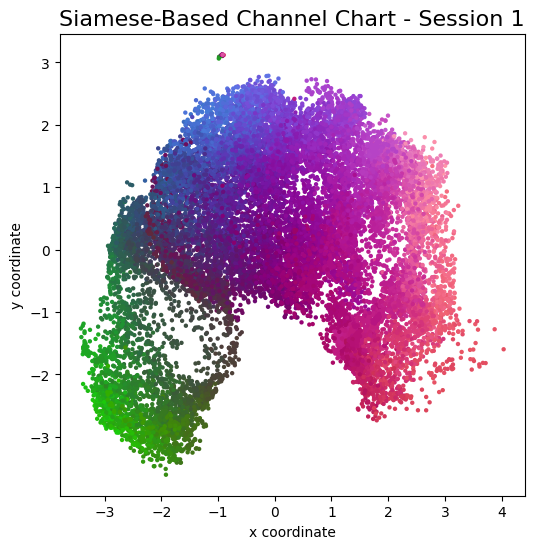


Training Session  2 
Batch Size:  1000 
Learning rate:  0.01
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0744
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


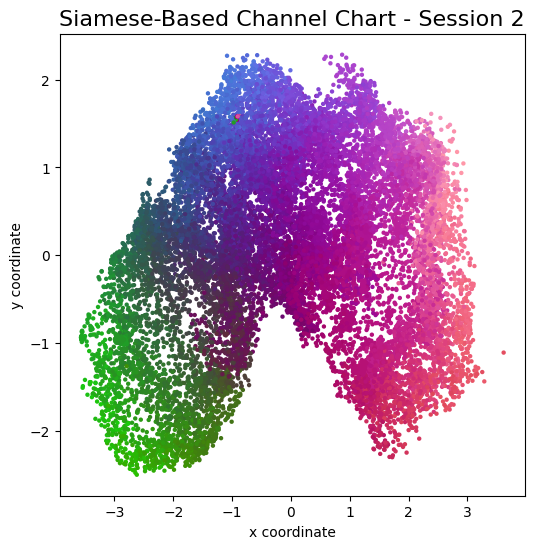


Training Session  3 
Batch Size:  1500 
Learning rate:  0.008
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0694
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


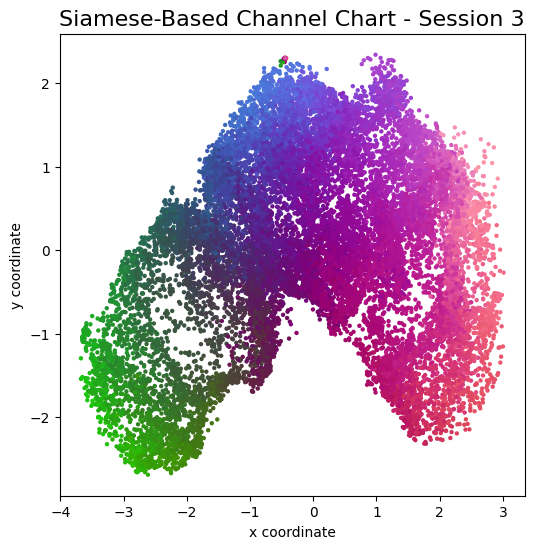


Training Session  4 
Batch Size:  2000 
Learning rate:  0.004
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0667
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


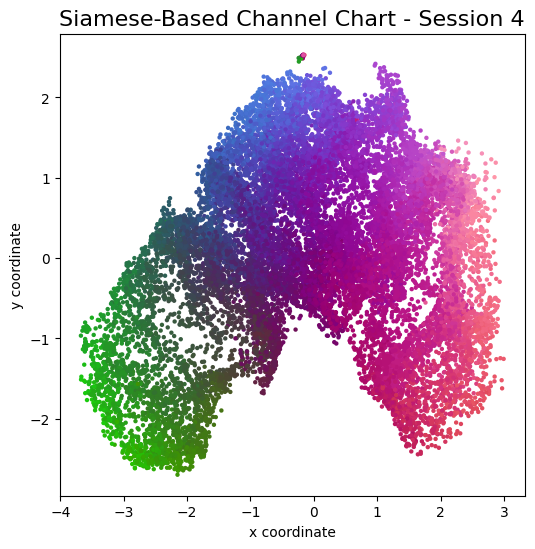


Training Session  5 
Batch Size:  3000 
Learning rate:  0.001
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0658
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


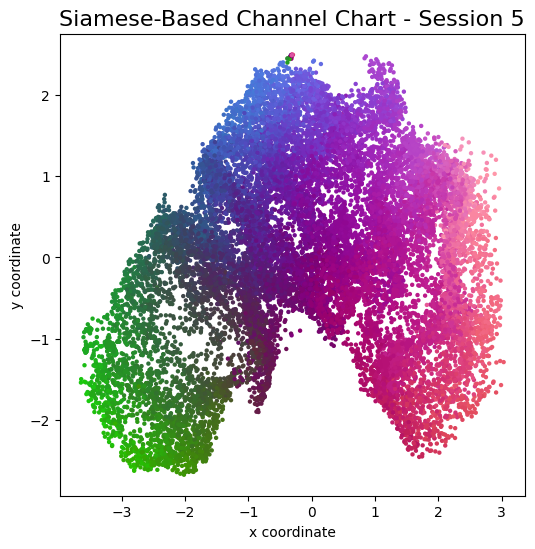


Training Session  6 
Batch Size:  4000 
Learning rate:  0.0005
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0639
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


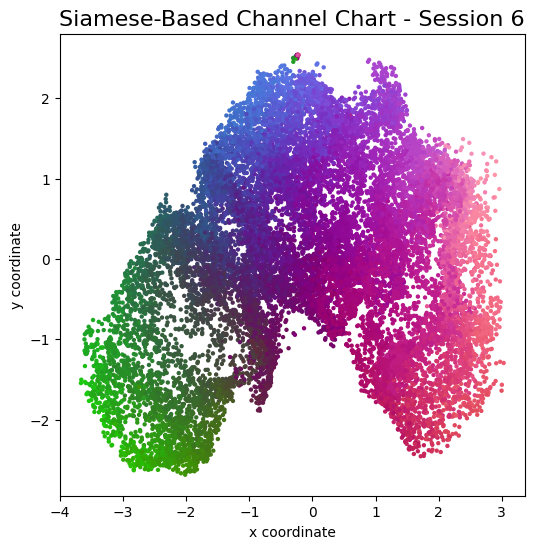


Training Session  7 
Batch Size:  5000 
Learning rate:  0.0002
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0636
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


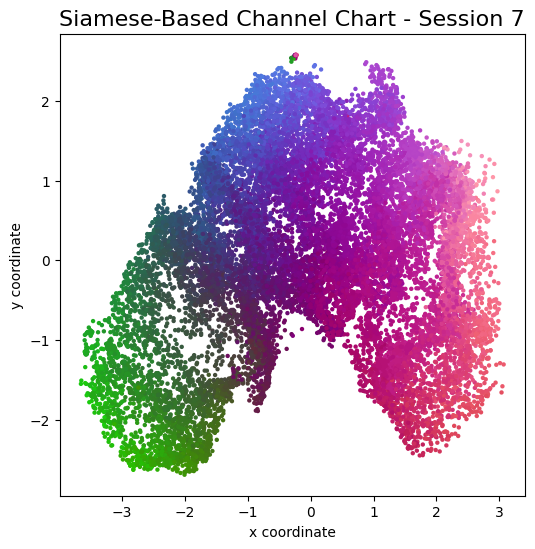


Training Session  8 
Batch Size:  6000 
Learning rate:  0.0001
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0645
Running inference to plot channel chart
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


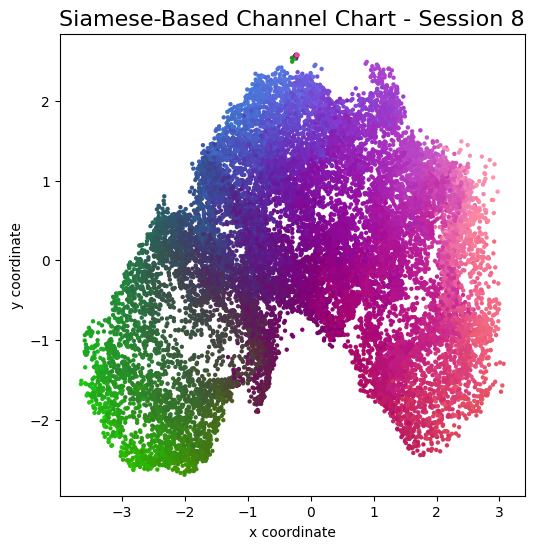

In [42]:
optimizer = tf.keras.optimizers.Adam()
model.compile(loss = siamese_loss, optimizer = optimizer)

samples_per_session = 150000
learning_rates = [1e-2, 1e-2, 8e-3, 4e-3, 1e-3, 5e-4, 2e-4, 1e-4]
batch_size = [500, 1000, 1500, 2000, 3000, 4000, 5000, 6000]

for l in range(len(learning_rates)):
    print("\nTraining Session ", l + 1, "\nBatch Size: ", batch_size[l], "\nLearning rate: ", learning_rates[l])

    # Fit model
    optimizer.learning_rate.assign(learning_rates[l])
    model.fit(random_pair_dataset.batch(batch_size[l]).prefetch(tf.data.AUTOTUNE), steps_per_epoch = samples_per_session // batch_size[l])

    # Plot Channel Chart
    print("Running inference to plot channel chart")
    channel_chart_positions = cc_embmodel.predict(csi_time_domain)
    plot_colorized(channel_chart_positions, groundtruth_positions, title = "Siamese-Based Channel Chart - Session " + str(l + 1))

# Evaluation: Optimal Affine Transform and Mean Absolute Error

657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


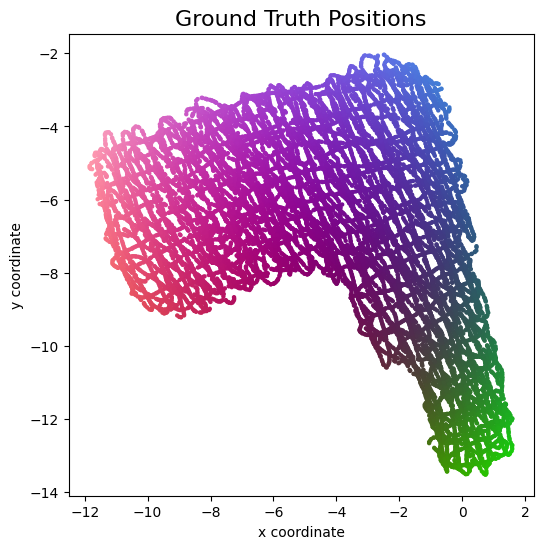

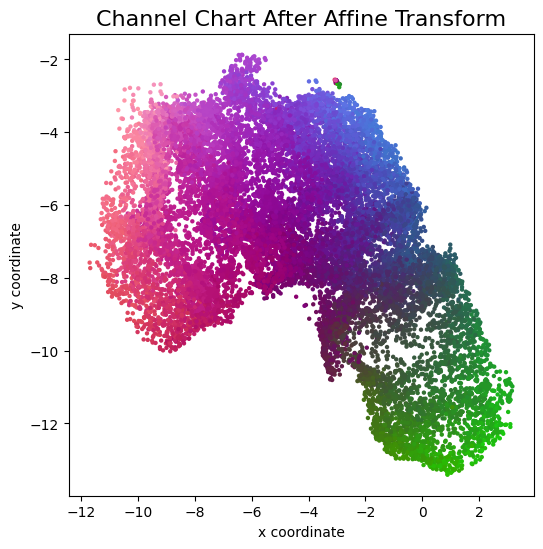

In [43]:
channel_chart_positions = cc_embmodel.predict(csi_time_domain)

def affine_transform_channel_chart(groundtruth_pos, channel_chart_pos):
    pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
    unpad = lambda x: x[:,:-1]
    A, res, rank, s = np.linalg.lstsq(pad(channel_chart_pos), pad(groundtruth_pos), rcond = None)
    transform = lambda x: unpad(np.dot(pad(x), A))
    return transform(channel_chart_pos)

channel_chart_positions_transformed = affine_transform_channel_chart(groundtruth_positions, channel_chart_positions)
plot_colorized(groundtruth_positions, groundtruth_positions, title = "Ground Truth Positions")
plot_colorized(channel_chart_positions_transformed, groundtruth_positions, title = "Channel Chart After Affine Transform")

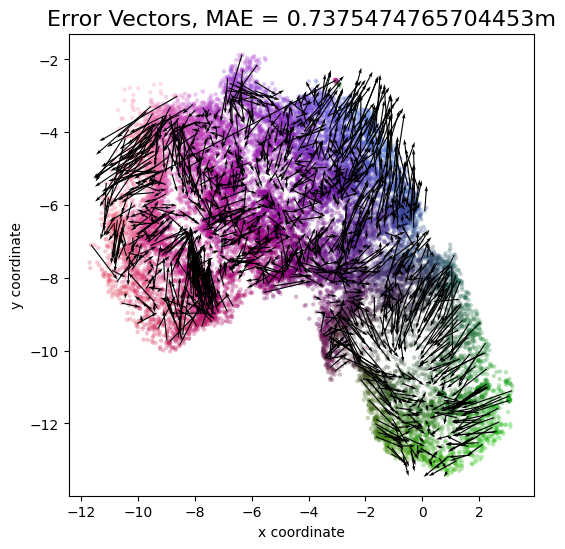

In [44]:
errorvectors = groundtruth_positions - channel_chart_positions_transformed
errors = np.sqrt(errorvectors[:,0]**2 + errorvectors[:,1]**2)
mae = np.mean(errors)

nth_errorvector = 15
plot_colorized(channel_chart_positions_transformed, groundtruth_positions, title = "Error Vectors, MAE = " + str(mae) + "m", show = False, alpha = 0.3)
plt.quiver(channel_chart_positions_transformed[::nth_errorvector, 0], channel_chart_positions_transformed[::nth_errorvector, 1], errorvectors[::nth_errorvector, 0], errorvectors[::nth_errorvector, 1], color = "black", angles = "xy", scale_units = "xy", scale = 1)
plt.show()

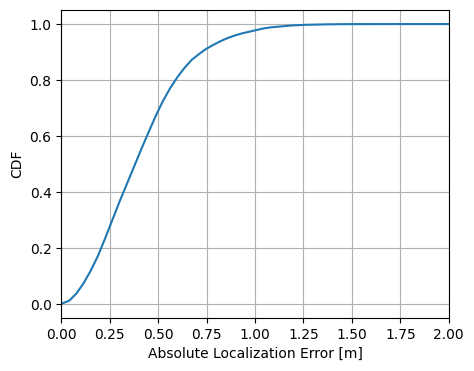

In [25]:
count, bins_count = np.histogram(errors, bins=200)
pdf = count / sum(count)
cdf = np.cumsum(pdf)

bins_count[0] = 0
cdf = np.append([0], cdf)

plt.figure(figsize=(5, 4))
plt.plot(bins_count, cdf)
plt.xlim((0, 2))
plt.xlabel("Absolute Localization Error [m]")
plt.ylabel("CDF")
plt.grid()
plt.show()

# Evaluation: Continuity, Trustworthiness, Kruskal Stress

In [45]:
# Continuity is identical to trustworthiness, except that original space and embedding space are swapped
def continuity(*args, **kwargs):
    args = list(args)
    args[0], args[1] = args[1], args[0]
    return trustworthiness(*args, **kwargs)

def kruskal_stress(X, X_embedded):
    dist_X = distance_matrix(X, X)
    dist_X_embedded = distance_matrix(X_embedded, X_embedded)
    beta = np.divide(np.sum(dist_X * dist_X_embedded), np.sum(dist_X_embedded * dist_X_embedded))

    return np.sqrt(np.divide(np.sum(np.square((dist_X - beta * dist_X_embedded))), np.sum(dist_X * dist_X)))

In [46]:
# Evaluate CT / TW / KS on a subset of the whole dataset
subset_indices = random.sample(range(len(groundtruth_positions)), len(groundtruth_positions) // 5)
groundtruth_positions_subset = groundtruth_positions[subset_indices]
channel_chart_positions_subset = channel_chart_positions[subset_indices]

ct = continuity(groundtruth_positions_subset, channel_chart_positions_subset, n_neighbors = int(0.05 * len(groundtruth_positions_subset)))
tw = trustworthiness(groundtruth_positions_subset, channel_chart_positions_subset, n_neighbors = int(0.05 * len(groundtruth_positions_subset)))
ks = kruskal_stress(groundtruth_positions_subset, channel_chart_positions_subset)

print("CT: {} \nTW: {} \nKS: {}".format(*np.around((ct, tw, ks), 4)))

CT: 0.9843 
TW: 0.9841 
KS: 0.1526
